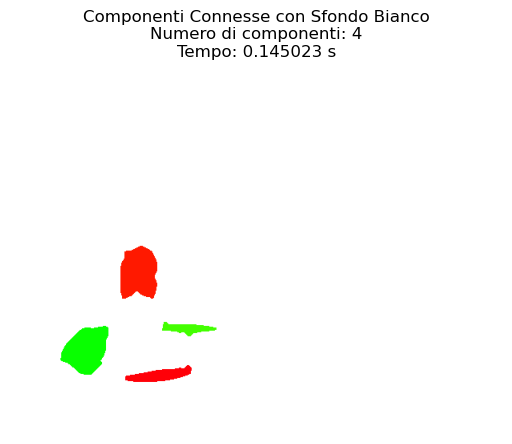

Tempo di esecuzione: 0.145023 secondi


In [20]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import time  # Importa il modulo per il timing

def connected_components_labeling(binary_image):
    h, w = binary_image.shape
    labels = np.zeros((h, w), dtype=np.int32)
    label_equivalences = {}
    next_label = 1

    # Passo 1: Assegnazione etichette provvisorie
    for i in range(h):
        for j in range(w):
            if binary_image[i, j] == 255:
                neighbors = []
                if j > 0 and labels[i, j - 1] > 0:
                    neighbors.append(labels[i, j - 1])
                if i > 0 and labels[i - 1, j] > 0:
                    neighbors.append(labels[i - 1, j])

                if not neighbors:
                    labels[i, j] = next_label
                    label_equivalences[next_label] = next_label
                    next_label += 1
                else:
                    min_label = min(neighbors)
                    labels[i, j] = min_label
                    for n in neighbors:
                        if n != min_label:
                            label_equivalences[n] = min_label

    # Passo 2: Risoluzione etichette equivalenti
    for i in range(h):
        for j in range(w):
            if labels[i, j] > 0:
                root = labels[i, j]
                while root != label_equivalences[root]:
                    root = label_equivalences[root]
                labels[i, j] = root

    unique_labels = np.unique(labels)
    num_labels = len(unique_labels) - (1 if 0 in unique_labels else 0)
    
    # Creazione immagine colorata con sfondo bianco
    label_hue = np.uint8(179 * labels / np.max(labels))
    blank_ch = 255 * np.ones_like(label_hue)
    labeled_img = cv2.merge([label_hue, blank_ch, blank_ch])
    labeled_img = cv2.cvtColor(labeled_img, cv2.COLOR_HSV2RGB)
    labeled_img[labels == 0] = [255, 255, 255]  # Sfondo bianco
    
    return labeled_img, num_labels

#%% Carica l'immagine e convertila in scala di grigi
beans_img = cv2.imread('000007.bmp')
img_gray = cv2.cvtColor(beans_img, cv2.COLOR_BGR2GRAY)

#%% Ritaglio dei bordi
height, width = img_gray.shape
border_x = int(height * 0.02)  
border_y = int(width * 0.02)   
img_cropped = img_gray[border_x:height-border_x, border_y:width-border_y]

#%% Segmentazione
threshold = 75
ret, img_segmented = cv2.threshold(img_cropped, threshold, 255, cv2.THRESH_BINARY_INV)

#%% Operazioni Morfologiche con Erosione più leggera
kernel_erode = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))  # Kernel più piccolo
img_eroded = cv2.erode(img_segmented, kernel_erode, iterations=22)  # Meno iterazioni

# Apertura per eliminare rumore residuo
kernel_open = np.ones((3,3), np.uint8)
img_opened = cv2.morphologyEx(img_eroded, cv2.MORPH_OPEN, kernel_open)

#%% Misurazione del tempo
start_time = time.time()  # Inizia il timer

labeled_img, num_labels = connected_components_labeling(img_opened)

end_time = time.time()  # Ferma il timer
execution_time = end_time - start_time  # Calcola il tempo trascorso

#%% Mostra solo l'ultima immagine con componenti connesse
plt.imshow(labeled_img)
plt.axis('off')
plt.title(f"Componenti Connesse con Sfondo Bianco\nNumero di componenti: {num_labels}\nTempo: {execution_time:.6f} s")
plt.show()

# Stampa il tempo di esecuzione in console
print(f"Tempo di esecuzione: {execution_time:.6f} secondi")
